## Install Packages

In [1]:
# Install all required third-party packages
%pip install numpy pandas matplotlib scipy scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Question 1: Entropy in Classification

This question discusses how entropy measures whether a partition or node in a classification problem is pure.

## Answer Summary

| Statement | Answer | Reason |
|---|---|---|
| (a) High entropy means the partitions are pure. | **False** | High entropy means the classes are mixed, so the partition is impure. |
| (b) High entropy means the partitions are impure. | **True** | In binary classification, entropy is highest when the two classes are close to a 50%/50% split. |

## Theoretical Explanation

For a node or partition in a classification problem, entropy is defined as:

$$H(S)=-\sum_{k=1}^{K}p_k\log_2(p_k)$$

where $p_k$ is the proportion of observations belonging to class $k$. Entropy measures the uncertainty of the class label, not the model error itself.

For a binary classification problem, if the positive-class probability is $p$ and the negative-class probability is $1-p$, then:

$$H(p)=-p\log_2(p)-(1-p)\log_2(1-p)$$

When almost all observations in a node belong to the same class, the class label is highly certain and entropy is close to 0. When the two classes are close to 50% and 50%, the class label is most uncertain and entropy reaches its maximum value of 1.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def binary_entropy(p):
    p = np.asarray(p, dtype=float)
    q = 1 - p
    out = np.zeros_like(p, dtype=float)
    mask = (p > 0) & (p < 1)
    out[mask] = -p[mask] * np.log2(p[mask]) - q[mask] * np.log2(q[mask])
    return out


examples = pd.DataFrame({"Positive class probability": [0.00, 0.10, 0.25, 0.50, 0.75, 0.90, 1.00]})
examples["Negative class probability"] = 1 - examples["Positive class probability"]
examples["Entropy"] = binary_entropy(examples["Positive class probability"]).round(4)
examples

,Positive class probability,Negative class probability,Entropy
0,0.00,1.00,0.0000
1,0.10,0.90,0.4690
2,0.25,0.75,0.8113
3,0.50,0.50,1.0000
4,0.75,0.25,0.8113
5,0.90,0.10,0.4690
6,1.00,0.00,0.0000


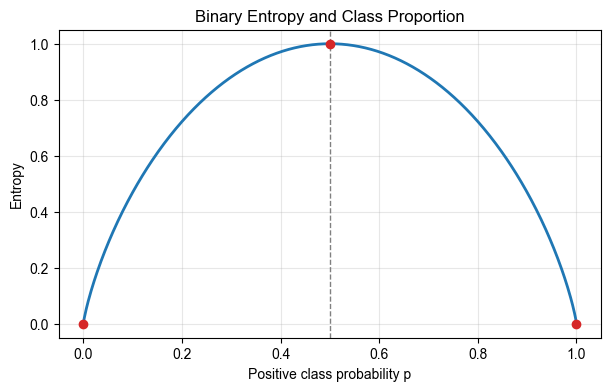

In [3]:
p = np.linspace(0, 1, 501)
h = binary_entropy(p)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, h, color="#1f77b4", linewidth=2)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.scatter([0, 0.5, 1], [0, 1, 0], color="#d62728", zorder=3)
ax.set_title("Binary Entropy and Class Proportion")
ax.set_xlabel("Positive class probability p")
ax.set_ylabel("Entropy")
ax.grid(True, alpha=0.3)
plt.show()

## Conclusion

Therefore, statement (a) is **False** and statement (b) is **True**. Lower entropy indicates that one class dominates the node and the partition is purer. Higher entropy indicates that different classes are more mixed and the partition is more impure. In decision trees, the preferred split is usually the one that reduces entropy the most, which is equivalent to maximizing information gain.

---

# Question 2: Feature Selection Using the Funnelling Approach

This question constructs a broad candidate feature set from CSI 300 index data and then applies filter, wrapper, and embedded methods to narrow the feature set step by step. The candidate features cover returns, volatility, trend, volume, candlestick structure, and technical indicators.

## Methodological Supplement: Three Types of Feature Selection

The feature-selection process uses a funnel because short-term market-direction prediction has a low signal-to-noise ratio. A single feature is unlikely to produce a strong and stable signal. Therefore, the selection process should not rely on only one technique. It should begin with a broad candidate set and then narrow it gradually.

- **Filter methods** select features based on statistical properties of the data or on the relationship between individual features and the target. They do not depend on the final model. Here I use correlation filtering and mutual information.
- **Wrapper methods** evaluate feature subsets through model training and cross-validation performance.
- **Embedded methods** use feature importance generated during model training, such as XGBoost gain importance.

Mutual information can be written as:

$$I(X;Y)=\sum_{x,y}p(x,y)\log\left(\frac{p(x,y)}{p(x)p(y)}\right)$$

It measures how much information feature $X$ shares with target $Y$. Unlike simple linear correlation, mutual information can capture nonlinear dependence, making it suitable as a preliminary screening metric before fitting a tree-based model.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform
from xgboost import XGBClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## Candidate Feature Construction

In [5]:
# Load file
df = pd.read_csv("CSI300_2005_2026.csv", parse_dates=["Date"]).sort_values("Date").set_index("Date")
df = df["2010":].copy()

# Core returns and price/volume structure
df["log_ret_1"] = np.log(df["Adj Close"]).diff()
df["simple_ret_1"] = df["Adj Close"].pct_change()
df["intraday_ret"] = df["Close"] / df["Open"] - 1
df["range_pct"] = df["High"] / df["Low"] - 1
df["gap_ret"] = df["Open"] / df["Close"].shift(1) - 1
df["upper_shadow"] = (df["High"] - df[["Open", "Close"]].max(axis=1)) / df["Close"]
df["lower_shadow"] = (df[["Open", "Close"]].min(axis=1) - df["Low"]) / df["Close"]
df["body_pct"] = (df["Close"] - df["Open"]) / df["Open"]
df["close_pos"] = (df["Close"] - df["Low"]) / (df["High"] - df["Low"]).replace(0, np.nan)
df["volume_ret"] = np.log(df["Volume"]).diff()
df["dow"] = df.index.dayofweek

# Rolling return, volatility, trend and volume features
for window in [2, 3, 5, 10, 20, 40, 60, 120]:
    df[f"ret_sum_{window}"] = df["log_ret_1"].rolling(window).sum()
    df[f"ret_mean_{window}"] = df["log_ret_1"].rolling(window).mean()
    df[f"volatility_{window}"] = df["log_ret_1"].rolling(window).std()
    df[f"ma_ratio_{window}"] = df["Adj Close"] / df["Adj Close"].rolling(window).mean() - 1
    df[f"volume_z_{window}"] = (
        df["Volume"] - df["Volume"].rolling(window).mean()
    ) / df["Volume"].rolling(window).std()
    df[f"rolling_min_ret_{window}"] = df["log_ret_1"].rolling(window).min()
    df[f"rolling_max_ret_{window}"] = df["log_ret_1"].rolling(window).max()

# RSI indicators
for window in [6, 14, 21]:
    delta = df["Adj Close"].diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    df[f"rsi_{window}"] = 100 - (100 / (1 + rs))

# MACD indicators
ema12 = df["Adj Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Adj Close"].ewm(span=26, adjust=False).mean()
df["macd"] = ema12 - ema26
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

# ATR indicators
true_range = pd.concat(
    [
        df["High"] - df["Low"],
        (df["High"] - df["Close"].shift(1)).abs(),
        (df["Low"] - df["Close"].shift(1)).abs(),
    ],
    axis=1,
).max(axis=1)
for window in [14, 20]:
    df[f"atr_{window}"] = true_range.rolling(window).mean() / df["Adj Close"]

# Target: effective next-day uptrend
target_threshold = 0.0015
df["next_log_ret"] = df["log_ret_1"].shift(-1)
df["Label"] = np.where(df["next_log_ret"] > target_threshold, 1, 0)
df.loc[df["next_log_ret"].isna(), "Label"] = np.nan

excluded = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "next_log_ret", "Label"]
features_list = [col for col in df.columns if col not in excluded]

data = df[features_list + ["Label", "next_log_ret"]].replace([np.inf, -np.inf], np.nan).dropna()
X = data[features_list]
y = data["Label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

pd.DataFrame({
    "Item": ["Usable observations", "Training observations", "Testing observations", "Candidate features", "Training positive rate", "Testing positive rate"],
    "Value": [len(data), len(X_train), len(X_test), len(features_list), round(y_train.mean(), 4), round(y_test.mean(), 4)],
})

,Item,Value
0,Usable observations,3779.0000
1,Training observations,3023.0000
2,Testing observations,756.0000
3,Candidate features,75.0000
4,Training positive rate,0.4436
5,Testing positive rate,0.4206


## Step 1: Filter Method

The filter step first removes redundant variables whose absolute pairwise correlation in the training set is greater than 0.98. It then ranks the remaining variables by mutual information.

In [6]:
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_dropped = [column for column in upper.columns if any(upper[column] > 0.98)]
corr_features = [column for column in X_train.columns if column not in corr_dropped]

mi_scores = pd.Series(
    mutual_info_classif(X_train[corr_features], y_train, random_state=42),
    index=corr_features,
).sort_values(ascending=False)

filter_features = list(mi_scores.head(min(64, len(mi_scores))).index)

print(f"Initial feature count: {len(features_list)}")
print(f"Dropped by correlation filter: {len(corr_dropped)}")
print(f"Features kept after filter step: {len(filter_features)}")
mi_scores.head(20).to_frame("mutual_information")

Initial feature count: 75
Dropped by correlation filter: 11
Features kept after filter step: 64


,mutual_information
rolling_max_ret_60,0.022335
ret_sum_3,0.015358
ret_sum_10,0.014109
ret_sum_60,0.013615
ma_ratio_3,0.011542
volatility_60,0.011495
volatility_120,0.010192
ret_sum_40,0.010145
rolling_min_ret_20,0.008746
log_ret_1,0.007698


## Step 2: Wrapper Method

The wrapper step uses XGBoost and `TimeSeriesSplit` to compare cross-validated ROC AUC for different numbers of selected features. Specifically, features are ranked by mutual information from the filter step, and subsets of increasing size (top 10, 15, 20, ...) are evaluated sequentially to find the best-performing subset size. Since the labels are mildly imbalanced, the model is trained with sample weights generated by `compute_sample_weight`.

In [7]:
tscv = TimeSeriesSplit(n_splits=5, gap=1)
base_selector_params = {
    "verbosity": 0,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
    "n_estimators": 120,
    "max_depth": 2,
    "learning_rate": 0.035,
    "subsample": 0.75,
    "colsample_bytree": 0.75,
    "min_child_weight": 5,
    "gamma": 1.0,
    "reg_alpha": 0.5,
    "reg_lambda": 3.0,
}

wrapper_rows = []
for n_features in [10, 15, 20, 25, 30, 35, 40, 50, len(filter_features)]:
    cols = filter_features[: min(n_features, len(filter_features))]
    selector_model = XGBClassifier(**base_selector_params)
    cv_scores = cross_val_score(
        selector_model,
        X_train[cols],
        y_train,
        cv=tscv,
        scoring="roc_auc",
        params={"sample_weight": sample_weights},
        n_jobs=1,
    )
    wrapper_rows.append({
        "n_features": len(cols),
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
        "features": cols,
    })

wrapper_table = pd.DataFrame(wrapper_rows).drop_duplicates("n_features")
best_wrapper = wrapper_table.sort_values(["cv_roc_auc_mean", "n_features"], ascending=[False, True]).iloc[0]
wrapper_features = list(best_wrapper["features"])

wrapper_table.drop(columns=["features"]).round(4)

,n_features,cv_roc_auc_mean,cv_roc_auc_std
0,10,0.5330,0.0312
1,15,0.5394,0.0235
2,20,0.5315,0.0253
3,25,0.5428,0.0219
4,30,0.5402,0.0252
5,35,0.5424,0.0238
6,40,0.5452,0.0300
7,50,0.5613,0.0291
8,64,0.5624,0.0307


## Step 3: Embedded Method

The embedded step trains XGBoost on the features selected by the wrapper step and ranks them by gain importance. A second time-series cross-validation step is then used to decide how many top-ranked features to retain.

In [8]:
embedded_model = XGBClassifier(**base_selector_params, importance_type="gain")
embedded_model.fit(X_train[wrapper_features], y_train, sample_weight=sample_weights)

gain_scores = pd.Series(
    embedded_model.feature_importances_,
    index=wrapper_features,
).sort_values(ascending=False)

embedded_rows = []
for n_features in [10, 15, 20, 25, 30, 35, 40, len(gain_scores)]:
    cols = list(gain_scores.head(min(n_features, len(gain_scores))).index)
    selector_model = XGBClassifier(**base_selector_params)
    cv_scores = cross_val_score(
        selector_model,
        X_train[cols],
        y_train,
        cv=tscv,
        scoring="roc_auc",
        params={"sample_weight": sample_weights},
        n_jobs=1,
    )
    embedded_rows.append({
        "n_features": len(cols),
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
        "features": cols,
    })

embedded_table = pd.DataFrame(embedded_rows).drop_duplicates("n_features")
best_embedded = embedded_table.sort_values(["cv_roc_auc_mean", "n_features"], ascending=[False, True]).iloc[0]
final_features = list(best_embedded["features"])

display(embedded_table.drop(columns=["features"]).round(4))

pd.DataFrame({
    "Rank": range(1, len(final_features) + 1),
    "Feature": final_features,
    "Gain": gain_scores.loc[final_features].round(6).values,
})

,n_features,cv_roc_auc_mean,cv_roc_auc_std
0,10,0.5739,0.0348
1,15,0.5765,0.0289
2,20,0.5716,0.0306
3,25,0.5705,0.0287
4,30,0.5659,0.0267
5,35,0.5579,0.0299
6,40,0.5653,0.0332
7,64,0.5582,0.0275


,Rank,Feature,Gain
0,1,ma_ratio_5,0.042444
1,2,ma_ratio_3,0.027477
2,3,ret_sum_5,0.026697
3,4,rolling_min_ret_3,0.025593
4,5,ret_sum_2,0.025003
5,6,volume_z_60,0.023298
6,7,rolling_min_ret_2,0.021828
7,8,ret_sum_10,0.021570
8,9,dow,0.021367
9,10,rsi_21,0.020941


## Feature Selection Conclusion

The final feature subset is determined by a three-stage funnel:
- correlation filtering and mutual information for initial screening
- time-series cross-validation for wrapper selection
- XGBoost gain importance plus another cross-validation check for embedded selection

This feature subset is used for model training and tuning in Question 3.

---

# Question 3: Predicting Positive Market Moves Using Gradient Boosting

I build an XGBoost binary classifier using CSI 300 index data. The objective is to predict whether the next trading day will produce an effective positive market move.

The section structure follows a standard machine-learning workflow, while the feature set and model parameters are designed and tuned for the CSI 300 dataset.

## XGBoost Model Background

XGBoost stands for Extreme Gradient Boosting. It is an ensemble method based on gradient-boosted decision trees. It sequentially adds new trees to correct the residual errors of the previous model and includes regularization terms to control model complexity.

For structured financial data, XGBoost is useful because it can capture nonlinear relationships, feature interactions, and variables measured on different scales.

At iteration $t$, the XGBoost objective can be written as:

$$Obj^{(t)}=\sum_{i=1}^{n} l\left(y_i,\hat{y}_i^{(t-1)}+f_t(x_i)\right)+\sum_{j=1}^{t}\Omega(f_j)$$

The first term is the training loss and the second term is the regularization penalty. The complexity of a tree is commonly written as:

$$\Omega(f)=\gamma T+\frac{1}{2}\lambda\sum_{j=1}^{T}w_j^2$$

where $T$ is the number of leaf nodes, $w_j$ is the weight of leaf $j$, $\gamma$ controls whether a leaf should be split further, and $\lambda$ is the L2 regularization parameter. Larger regularization values make the model more conservative and help reduce overfitting.

## Import Libraries

In [9]:
# Data manipulation
from pathlib import Path
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Classifier
from xgboost import XGBClassifier, plot_importance

# Preprocessing and validation
from scipy.stats import loguniform, randint, uniform
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.utils.class_weight import compute_sample_weight

# Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)

plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

if Path.cwd().name != "Exam3" and (Path.cwd() / "Exam3").exists():
    os.chdir(Path.cwd() / "Exam3")

DATA_PATH = Path("CSI300_2005_2026.csv")

## Section 1: Experiment Tracking

The experiment record includes the asset, sample period, target definition, train-test split, cross-validation method, tuning space, and final evaluation metrics.

In [10]:
# Experiment Tracker
experiment_config = {
    "asset": "CSI 300 Index",
    "data": str(DATA_PATH),
    "target": "next-day effective uptrend",
    "target_threshold": 0.0015,
    "test_size": 0.2,
    "random_state": 42,
}

pd.DataFrame(experiment_config.items(), columns=["Item", "Value"])

,Item,Value
0,asset,CSI 300 Index
1,data,CSI300_2005_2026.csv
2,target,next-day effective uptrend
3,target_threshold,0.0015
4,test_size,0.2
5,random_state,42


## Section 2: The workflow

We'll employ XGBoost classifier from `scikit-learn` for stock / equity index trend prediction.

| Steps        | Workflow                  | Remarks                                                         |
|:-------------|:--------------------------|:----------------------------------------------------------------|
|Step 1        | Ideation                  | Define objective, success metrics     |
|Step 2        | Data Collection           | Gather and integrate data
|Step 3        | Exploratory Data Analysis (Initial) | Broad exploration: stats, distributions, correlations, missing data |
|Step 4        | Data Cleaning           | Handle missing values, outliers, duplicates.            |
|Step 5        | Feature Engineering & Transformation            | Feature creation, scaling, encoding, selection                         |
|        | Subset Validation EDA            | Re-examine chosen features: check distributions, multicollinearity, relationships                      |               
|Step 6        | Modeling                  | Select algorithm(s), train models, tune hyperparameters                           |
|Step 7        | Evaluation                   | Validate using metrics and backtesting       |

### (1) Load Data

The study uses daily OHLCV data for the CSI 300 index. `Adj Close` is used for return calculation because it provides a comparable price series. The sample starts in 2010 to retain a sufficiently long training history while reducing the influence of very early market regimes.

In [11]:
# Load file
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").set_index("Date")
df = df["2010":].copy()

# Calculate returns
df["log_ret_1"] = np.log(df["Adj Close"]).diff()

# Verify the output
df.head()

,Open,High,Low,Close,Adj Close,Volume,log_ret_1
Date,,,,,,,
2010-01-04,3592.47,3597.75,3535.23,3535.23,3535.23,66101080,NaN
2010-01-05,3545.19,3577.53,3497.66,3564.04,3564.04,85809641,0.008116
2010-01-06,3558.70,3588.83,3541.17,3541.73,3541.73,78473125,-0.006279
2010-01-07,3543.16,3558.56,3452.77,3471.46,3471.46,80350037,-0.020040
2010-01-08,3456.91,3482.08,3426.70,3480.13,3480.13,60790253,0.002494


### (2) EDA of Original dataset

In [12]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,3973.0,3.562831e+03,8.046580e+02,2.079870e+03,3.055210e+03,3.569730e+03,4.022710e+03,5.922070e+03
High,3973.0,3.591093e+03,8.095178e+02,2.118790e+03,3.078440e+03,3.596510e+03,4.055780e+03,5.930910e+03
Low,3973.0,3.535276e+03,7.977785e+02,2.023170e+03,3.027050e+03,3.542280e+03,3.994600e+03,5.747660e+03
Close,3973.0,3.565183e+03,8.044157e+02,2.086970e+03,3.056910e+03,3.572360e+03,4.022030e+03,5.807720e+03
Adj Close,3973.0,3.565183e+03,8.044157e+02,2.086970e+03,3.056910e+03,3.572360e+03,4.022030e+03,5.807720e+03
Volume,3973.0,1.279462e+08,8.352239e+07,2.190125e+07,7.291943e+07,1.089635e+08,1.563590e+08,6.864391e+08
log_ret_1,3972.0,7.638606e-05,1.361843e-02,-9.154437e-02,-6.321207e-03,1.781551e-04,6.755538e-03,8.142001e-02


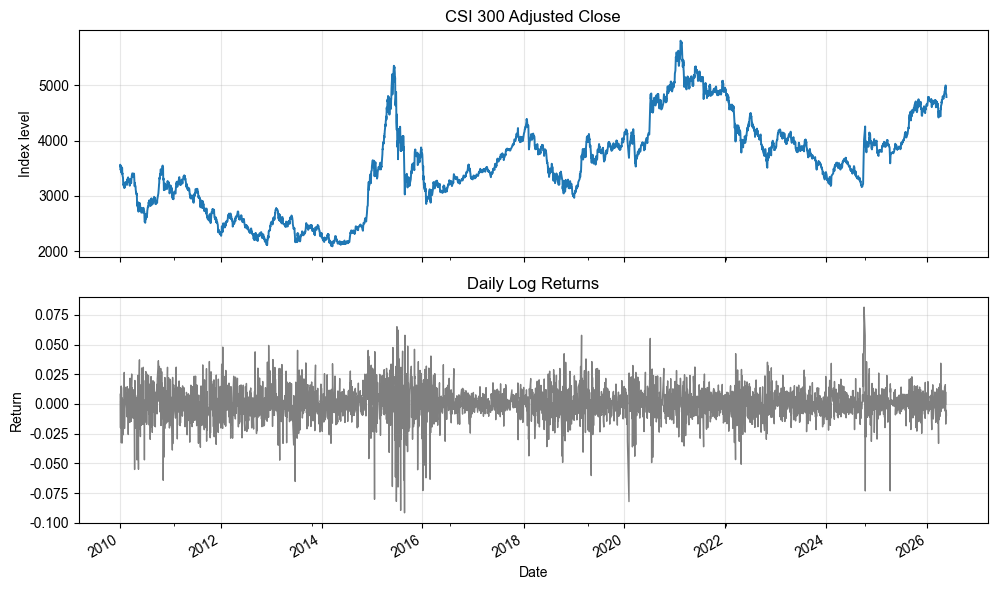

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df["Adj Close"].plot(ax=axes[0], color="#1f77b4", linewidth=1.4)
axes[0].set_title("CSI 300 Adjusted Close")
axes[0].set_ylabel("Index level")
axes[0].grid(True, alpha=0.3)

df["log_ret_1"].plot(ax=axes[1], color="#7f7f7f", linewidth=1.0)
axes[1].set_title("Daily Log Returns")
axes[1].set_ylabel("Return")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (3) Cleaning & Imputation

The cleaning step checks missing values, duplicate dates, and unreasonable prices or volumes. For time-series modeling, missing values should not be filled using future information. The original OHLCV fields are complete; missing values naturally created by rolling features and forward labels are removed after feature engineering.

In [14]:
# Check for missing values
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
log_ret_1    1
dtype: int64

### (4) Feature Engineering

The candidate features include rolling returns and rolling volatility as well as moving-average deviations, standardized volume, recent extreme returns, candlestick structure, RSI, MACD, and ATR.

Feature engineering transforms raw OHLCV data into variables that describe trend, reversal, volatility, trading activity, and intraday price structure. The core log return is defined as:

$$r_t=\log\left(\frac{P_t}{P_{t-1}}\right)$$

Rolling cumulative return and rolling volatility are defined as:

$$Ret_{t,w}=\sum_{i=0}^{w-1}r_{t-i}$$

$$Std_{t,w}=\sqrt{\frac{1}{w-1}\sum_{i=0}^{w-1}\left(r_{t-i}-\bar{r}_{t,w}\right)^2}$$

The moving-average deviation measures the price relative to its historical average:

$$\mathrm{MA\_ratio}_{t,w}=\frac{P_t}{MA_{t,w}}-1$$

The standardized volume variable is a rolling z-score:

$$VolumeZ_{t,w}=\frac{Volume_t-\overline{Volume}_{t,w}}{\sigma(Volume)_{t,w}}$$

Together, these variables form a richer candidate feature set than a single return or volatility measure.

In [15]:
# Core returns and price/volume structure
df["simple_ret_1"] = df["Adj Close"].pct_change()
df["intraday_ret"] = df["Close"] / df["Open"] - 1
df["range_pct"] = df["High"] / df["Low"] - 1
df["gap_ret"] = df["Open"] / df["Close"].shift(1) - 1
df["upper_shadow"] = (df["High"] - df[["Open", "Close"]].max(axis=1)) / df["Close"]
df["lower_shadow"] = (df[["Open", "Close"]].min(axis=1) - df["Low"]) / df["Close"]
df["body_pct"] = (df["Close"] - df["Open"]) / df["Open"]
df["close_pos"] = (df["Close"] - df["Low"]) / (df["High"] - df["Low"]).replace(0, np.nan)
df["volume_ret"] = np.log(df["Volume"]).diff()
df["dow"] = df.index.dayofweek

# Create features (predictors) list
features_list = [
    "log_ret_1", "simple_ret_1", "intraday_ret", "range_pct", "gap_ret",
    "upper_shadow", "lower_shadow", "body_pct", "close_pos", "volume_ret", "dow",
]

for window in [2, 3, 5, 10, 20, 40, 60, 120]:
    df[f"ret_sum_{window}"] = df["log_ret_1"].rolling(window).sum()
    df[f"ret_mean_{window}"] = df["log_ret_1"].rolling(window).mean()
    df[f"volatility_{window}"] = df["log_ret_1"].rolling(window).std()
    df[f"ma_ratio_{window}"] = df["Adj Close"] / df["Adj Close"].rolling(window).mean() - 1
    df[f"volume_z_{window}"] = (
        df["Volume"] - df["Volume"].rolling(window).mean()
    ) / df["Volume"].rolling(window).std()
    df[f"rolling_min_ret_{window}"] = df["log_ret_1"].rolling(window).min()
    df[f"rolling_max_ret_{window}"] = df["log_ret_1"].rolling(window).max()
    features_list += [
        f"ret_sum_{window}", f"ret_mean_{window}", f"volatility_{window}",
        f"ma_ratio_{window}", f"volume_z_{window}",
        f"rolling_min_ret_{window}", f"rolling_max_ret_{window}",
    ]

for window in [6, 14, 21]:
    delta = df["Adj Close"].diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    df[f"rsi_{window}"] = 100 - (100 / (1 + rs))
    features_list.append(f"rsi_{window}")

ema12 = df["Adj Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Adj Close"].ewm(span=26, adjust=False).mean()
df["macd"] = ema12 - ema26
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]
features_list += ["macd", "macd_signal", "macd_hist"]

true_range = pd.concat(
    [
        df["High"] - df["Low"],
        (df["High"] - df["Close"].shift(1)).abs(),
        (df["Low"] - df["Close"].shift(1)).abs(),
    ],
    axis=1,
).max(axis=1)
for window in [14, 20]:
    df[f"atr_{window}"] = true_range.rolling(window).mean() / df["Adj Close"]
    features_list.append(f"atr_{window}")

# Define the forward return and label before dropping NaN values.
target_threshold = experiment_config["target_threshold"]
df["next_log_ret"] = df["log_ret_1"].shift(-1)
df["Label"] = np.where(df["next_log_ret"] > target_threshold, 1, 0)
df.loc[df["next_log_ret"].isna(), "Label"] = np.nan

# Drop NaN values
df = df[features_list + ["Label", "next_log_ret"]].replace([np.inf, -np.inf], np.nan).dropna()

print(f"Candidate feature count: {len(features_list)}")
print(f"Usable observations: {len(df)}")

Candidate feature count: 75
Usable observations: 3779


#### (a) Feature Specification

In [16]:
# Convert to NumPy
X_all = df[features_list]
X_all.head(2)

,log_ret_1,simple_ret_1,intraday_ret,range_pct,gap_ret,upper_shadow,lower_shadow,body_pct,close_pos,volume_ret,...,rolling_min_ret_120,rolling_max_ret_120,rsi_6,rsi_14,rsi_21,macd,macd_signal,macd_hist,atr_14,atr_20
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-05,-0.008501,-0.008465,0.002114,0.021377,-0.010556,0.006678,0.012282,0.002114,0.683037,-0.333451,...,-0.055093,0.03711,3.350021,23.402730,32.369203,-80.047899,-63.288774,-16.759125,0.023266,0.023117
2010-07-06,0.019801,0.019999,0.023167,0.024164,-0.003096,0.000199,0.000757,0.023167,0.991567,0.210422,...,-0.055093,0.03711,21.550067,29.905871,35.966139,-79.511873,-66.533394,-12.978479,0.023601,0.022833


In [17]:
# Feature subset derived by the funnelling approach.
y_for_selection = df["Label"].astype(int).values
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y_for_selection, test_size=0.2, shuffle=False
)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

corr = X_train_all.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_dropped = [column for column in upper.columns if any(upper[column] > 0.98)]
corr_features = [column for column in X_train_all.columns if column not in corr_dropped]

mi_scores = pd.Series(
    mutual_info_classif(X_train_all[corr_features], y_train, random_state=42),
    index=corr_features,
).sort_values(ascending=False)
filter_features = list(mi_scores.head(min(64, len(mi_scores))).index)

tscv = TimeSeriesSplit(n_splits=5, gap=1)
base_selector_params = {
    "verbosity": 0,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
    "n_estimators": 120,
    "max_depth": 2,
    "learning_rate": 0.035,
    "subsample": 0.75,
    "colsample_bytree": 0.75,
    "min_child_weight": 5,
    "gamma": 1.0,
    "reg_alpha": 0.5,
    "reg_lambda": 3.0,
}

wrapper_rows = []
for n_features in [10, 15, 20, 25, 30, 35, 40, 50, len(filter_features)]:
    cols = filter_features[: min(n_features, len(filter_features))]
    selector_model = XGBClassifier(**base_selector_params)
    cv_scores = cross_val_score(
        selector_model,
        X_train_all[cols],
        y_train,
        cv=tscv,
        scoring="roc_auc",
        params={"sample_weight": sample_weights},
        n_jobs=1,
    )
    wrapper_rows.append({
        "n_features": len(cols),
        "cv_roc_auc_mean": cv_scores.mean(),
        "features": cols,
    })

wrapper_table = pd.DataFrame(wrapper_rows).drop_duplicates("n_features")
best_wrapper = wrapper_table.sort_values(["cv_roc_auc_mean", "n_features"], ascending=[False, True]).iloc[0]
wrapper_features = list(best_wrapper["features"])

embedded_model = XGBClassifier(**base_selector_params, importance_type="gain")
embedded_model.fit(X_train_all[wrapper_features], y_train, sample_weight=sample_weights)
gain_scores = pd.Series(embedded_model.feature_importances_, index=wrapper_features).sort_values(ascending=False)

embedded_rows = []
for n_features in [10, 15, 20, 25, 30, 35, 40, len(gain_scores)]:
    cols = list(gain_scores.head(min(n_features, len(gain_scores))).index)
    selector_model = XGBClassifier(**base_selector_params)
    cv_scores = cross_val_score(
        selector_model,
        X_train_all[cols],
        y_train,
        cv=tscv,
        scoring="roc_auc",
        params={"sample_weight": sample_weights},
        n_jobs=1,
    )
    embedded_rows.append({
        "n_features": len(cols),
        "cv_roc_auc_mean": cv_scores.mean(),
        "features": cols,
    })

embedded_table = pd.DataFrame(embedded_rows).drop_duplicates("n_features")
best_embedded = embedded_table.sort_values(["cv_roc_auc_mean", "n_features"], ascending=[False, True]).iloc[0]
final_features = list(best_embedded["features"])

X = df[final_features]

pd.DataFrame({
    "Rank": range(1, len(final_features) + 1),
    "Feature": final_features,
    "Gain": gain_scores.loc[final_features].round(6).values,
})

,Rank,Feature,Gain
0,1,ma_ratio_5,0.042444
1,2,ma_ratio_3,0.027477
2,3,ret_sum_5,0.026697
3,4,rolling_min_ret_3,0.025593
4,5,ret_sum_2,0.025003
5,6,volume_z_60,0.023298
6,7,rolling_min_ret_2,0.021828
7,8,ret_sum_10,0.021570
8,9,dow,0.021367
9,10,rsi_21,0.020941


#### (b) Target or Label Definition

The label is the dependent variable in supervised learning. The goal is to predict whether the next trading day produces an effective uptrend, so the target is encoded as a 0/1 binary variable rather than -1/1. Let $P_t$ denote the adjusted close on day $t$. The next-day log return is:

$$r_{t+1}=\log\left(\frac{P_{t+1}}{P_t}\right)$$

Very small near-zero positive returns are grouped with the non-uptrend class. The threshold is set to $\theta=0.15\%$. The label is defined as:

$$
y_t=\begin{cases}
1, & \text{if } r_{t+1}>\theta,\\
0, & \text{otherwise.}
\end{cases}
$$

This choice reflects the fact that daily index returns contain many near-zero random movements. Treating every tiny positive return as an uptrend may cause the model to learn noise rather than an economically meaningful trend.

In [18]:
# Define Target
y = df["Label"].astype(int).values
y

array([1, 1, 0, ..., 0, 0, 0], shape=(3779,))

In [19]:
# label count
class_labels = np.bincount(y)
class_labels

array([2120, 1659])

### (5) Boosting Ensemble

This section first builds a baseline XGBoost model and then compares it with the tuned model. The data are split chronologically with `shuffle=False` to avoid look-ahead bias. Because the positive and negative classes are not perfectly balanced, `compute_sample_weight` is used so that the minority class receives higher weight during training.

The baseline model provides a reference point. If the tuned model cannot improve on the baseline, then hyperparameter tuning may not be producing a stable gain.

In [20]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 3023, 756


In [21]:
# Scale and fit the classifier model

# For binary or multiclass classification
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

base_model = XGBClassifier(
    verbosity=0,
    eval_metric="logloss",
)

base_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [22]:
# Predicting the test dataset
y_pred = base_model.predict(X_test)

# Predict Probabilities
y_proba = base_model.predict_proba(X_test)

In [23]:
# Accuracy Scores
acc_train = accuracy_score(y_train, base_model.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}")

Train Accuracy: 0.9997, Test Accuracy: 0.5198


In [24]:
# Balanced Accuracy Scores
bal_acc_train = balanced_accuracy_score(y_train, base_model.predict(X_train))
bal_acc_test = balanced_accuracy_score(y_test, y_pred)

print(f"Train Balanced Accuracy: {bal_acc_train:0.4}, Test Balanced Accuracy: {bal_acc_test:0.4}")

Train Balanced Accuracy: 0.9996, Test Balanced Accuracy: 0.5193


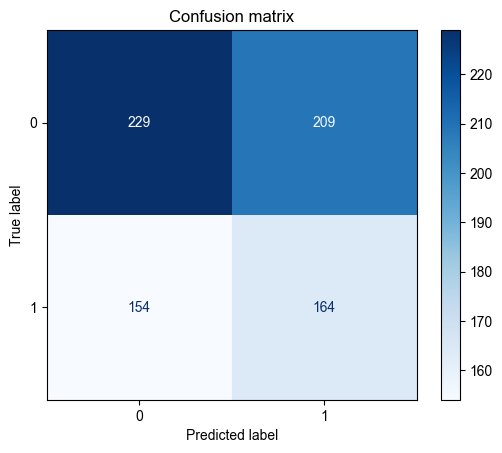

In [25]:
# Display confussion matrix
disp_cm = ConfusionMatrixDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    display_labels=base_model.classes_,
    cmap=plt.cm.Blues,
)
disp_cm.ax_.set_title("Confusion matrix")
plt.show()

In [26]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.52      0.56       438
           1       0.44      0.52      0.47       318

    accuracy                           0.52       756
   macro avg       0.52      0.52      0.52       756
weighted avg       0.53      0.52      0.52       756



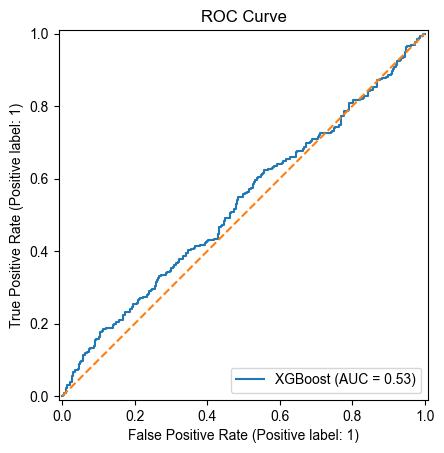

In [27]:
# Display ROCCurve
disp_roc = RocCurveDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    name="XGBoost",
)

disp_roc.ax_.set_title("ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

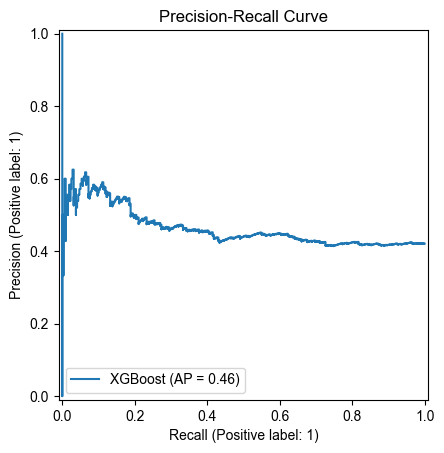

In [28]:
# Display PR Curve
disp_pr = PrecisionRecallDisplay.from_estimator(
    base_model,
    X_test,
    y_test,
    name="XGBoost",
)

disp_pr.ax_.set_title("Precision-Recall Curve")
plt.show()

### (6) Hyperparameter Tuning

Hyperparameters are not learned directly from the data. They are set or searched before model fitting. For XGBoost, common hyperparameters include tree depth, learning rate, number of trees, row subsampling, column subsampling, leaf-splitting constraints, and regularization strength.

I use `TimeSeriesSplit` for cross-validation. Unlike random K-fold validation, time-series cross-validation preserves chronological order. In each fold, the model is trained on earlier observations and validated on later observations, which is more appropriate for out-of-sample financial forecasting.

#### (a) XGBoost's hyper-parameter

The main tuning parameters are:

- `learning_rate`: the step size contribution of each tree. A smaller value is usually more stable but requires more trees.
- `max_depth`: the maximum depth of each tree. Deeper trees can capture more complex nonlinear patterns but are more prone to overfitting.
- `min_child_weight`: the minimum sum of instance weights required in a child node. A larger value makes splitting more conservative.
- `gamma`: the minimum loss reduction required for a further split. A larger value suppresses weak splits.
- `subsample` and `colsample_bytree`: row and feature sampling ratios, which help reduce overfitting.
- `reg_alpha` and `reg_lambda`: L1 and L2 regularization terms used to penalize overly complex trees.

In [29]:
# Timeseries Cross Validation 2-split Demonstration
tscv_demo = TimeSeriesSplit(n_splits=2, gap=1)
for train, test in tscv_demo.split(X):
    print(f"Train: {train}, Test: {test}")

Train: [   0    1    2 ... 1257 1258 1259], Test: [1261 1262 1263 ... 2517 2518 2519]
Train: [   0    1    2 ... 2516 2517 2518], Test: [2520 2521 2522 ... 3776 3777 3778]


In [30]:
# Cross-validation
tscv = TimeSeriesSplit(n_splits=5, gap=1)

In [31]:
# Get params list
base_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': 0}

#### (b) Randomized Search

Parameter search can be performed using grid search, random search, or Bayesian search. Grid search evaluates every combination in a predefined grid but can be expensive in high-dimensional spaces. Random search samples parameter combinations from specified distributions for a fixed number of iterations, often exploring the space more efficiently. I use randomized search and optimize cross-validated ROC AUC.

ROC AUC measures the model's ability to rank positive and negative observations, rather than its accuracy at a single fixed classification threshold. In financial direction prediction, ranking ability is often more stable than accuracy at one particular threshold.

In [32]:
# Randomized search configuration
param_dist = {
    "n_estimators": randint(60, 350),
    "max_depth": randint(1, 4),
    "learning_rate": loguniform(0.01, 0.12),
    "subsample": uniform(0.60, 0.40),
    "colsample_bytree": uniform(0.60, 0.40),
    "min_child_weight": randint(2, 18),
    "gamma": uniform(0, 6),
    "reg_alpha": loguniform(1e-4, 8),
    "reg_lambda": loguniform(0.5, 20),
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(verbosity=0, eval_metric="logloss", tree_method="hist", random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=1,
)

search.fit(X_train, y_train, sample_weight=sample_weights)
best_params = search.best_params_

print("Best parameters found by randomized search:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best cv/roc_auc_mean: {search.best_score_:.4f}")

Best parameters found by randomized search:
  colsample_bytree: 0.6888431241882921
  gamma: 0.7191922040020968
  learning_rate: 0.023139179833866045
  max_depth: 3
  min_child_weight: 12
  n_estimators: 219
  reg_alpha: 0.03496850801101574
  reg_lambda: 6.687265276473394
  subsample: 0.7454518409517176
Best cv/roc_auc_mean: 0.5813


In [33]:
# Create tuned model using best parameters
tuned_model = XGBClassifier(
    **best_params,
    verbosity=0,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

# Fit with evaluation tracking
tuned_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

print("Tuned model training completed successfully!")

Tuned model training completed successfully!


In [34]:
# Return the evaluation results
evals_result = tuned_model.evals_result()
pd.DataFrame({
    "train_logloss": evals_result["validation_0"]["logloss"],
    "test_logloss": evals_result["validation_1"]["logloss"],
}).tail()

,train_logloss,test_logloss
214,0.637914,0.683090
215,0.637791,0.683120
216,0.637722,0.683110
217,0.637616,0.683177
218,0.637409,0.683089


In [35]:
# Cross validation score with tuned model
cv_scores = cross_val_score(
    tuned_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="f1",
    params={"sample_weight": sample_weights},
    n_jobs=1,
)
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Mean CV Score: 0.4776 (+/- 0.1138)


In [36]:
# Predicting the test dataset
y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)

# Measure Accuracy
acc_train = accuracy_score(y_train, tuned_model.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

print(f"\n Training Accuracy \t: {acc_train :0.4} \n Test Accuracy \t\t: {acc_test :0.4}")


 Training Accuracy 	: 0.6659 
 Test Accuracy 		: 0.5635


In [37]:
bal_acc_train = balanced_accuracy_score(y_train, tuned_model.predict(X_train))
bal_acc_test = balanced_accuracy_score(y_test, y_pred)

print(f"Train Balanced Accuracy: {bal_acc_train:0.4}, Test Balanced Accuracy: {bal_acc_test:0.4}")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba[:, 1]):0.4}")
print(f"Test F1: {f1_score(y_test, y_pred):0.4}")
print(f"Test Precision: {precision_score(y_test, y_pred):0.4}")
print(f"Test Recall: {recall_score(y_test, y_pred):0.4}")

Train Balanced Accuracy: 0.6651, Test Balanced Accuracy: 0.5557
Test ROC AUC: 0.5693
Test F1: 0.4939
Test Precision: 0.482
Test Recall: 0.5063


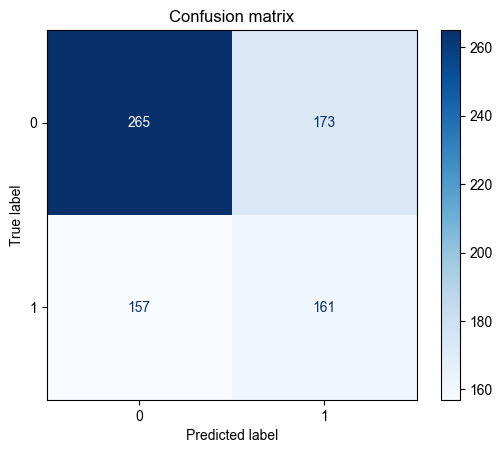

              precision    recall  f1-score   support

           0       0.63      0.61      0.62       438
           1       0.48      0.51      0.49       318

    accuracy                           0.56       756
   macro avg       0.55      0.56      0.56       756
weighted avg       0.57      0.56      0.56       756



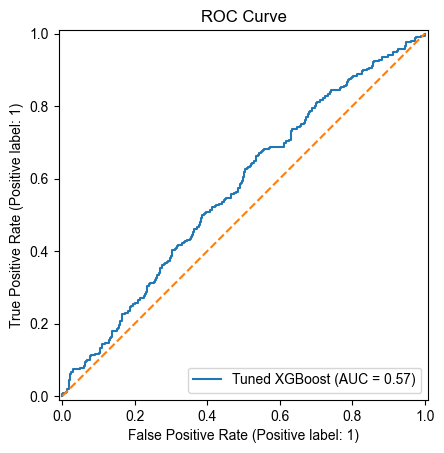

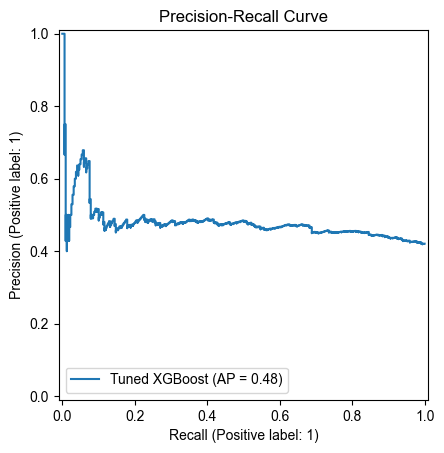

In [38]:
# Tuned Model: Evaluation

# Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    display_labels=tuned_model.classes_,
    cmap=plt.cm.Blues,
)
disp.ax_.set_title("Confusion matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

# ROC Curve
disp_roc = RocCurveDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    name="Tuned XGBoost",
)
disp_roc.ax_.set_title("ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

# PR Curve
disp_pr = PrecisionRecallDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    name="Tuned XGBoost",
)
disp_pr.ax_.set_title("Precision-Recall Curve")
plt.show()

### (7) Evaluation

Model evaluation is performed from two perspectives. The first is statistical prediction quality, including ROC AUC, confusion matrix, precision, recall, and F1-score. The second is economic interpretation, where predicted signals are converted into a simple trading strategy and evaluated through cumulative return and drawdown.

For a binary classifier, precision and recall are defined as:

$$Precision=\frac{TP}{TP+FP}$$

$$Recall=\frac{TP}{TP+FN}$$

F1-score is the harmonic mean of precision and recall:

$$F1=2\times\frac{Precision\times Recall}{Precision+Recall}$$

#### (a) Feature Importance

Feature importance helps explain which input variables the model relies on most. Common XGBoost importance types include:

- `weight`: the number of times a feature is used for splitting.
- `gain`: the average loss reduction produced by splits using the feature.
- `cover`: the average number of observations covered by splits using the feature.
- `total_gain`: the total loss reduction produced by all splits using the feature.


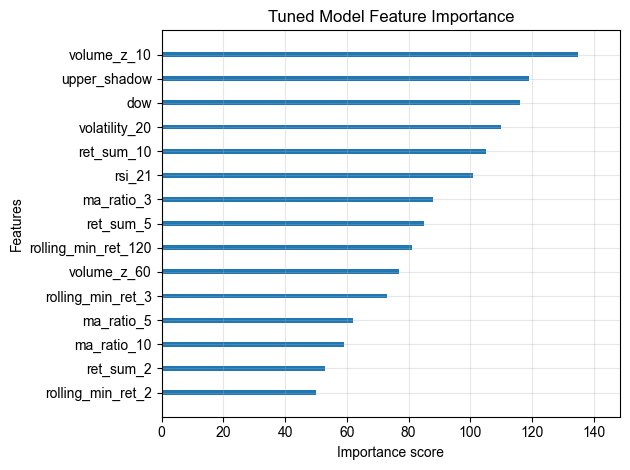

In [39]:
# Plot the feature importance of the tuned model
plot_importance(tuned_model, importance_type="weight", title="Tuned Model Feature Importance", show_values=False)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# The Gain is the most relevant attribute to interpret the relative importance of each feature.
gain_importance = tuned_model.get_booster().get_score(importance_type="gain")
pd.Series(gain_importance).sort_values(ascending=False).to_frame("gain")

,gain
dow,7.122242
rolling_min_ret_3,6.761382
ma_ratio_3,6.172990
rsi_21,6.066957
volume_z_60,5.551719
ma_ratio_5,5.498523
ma_ratio_10,5.474903
volume_z_10,5.432395
upper_shadow,5.389249
volatility_20,5.285149


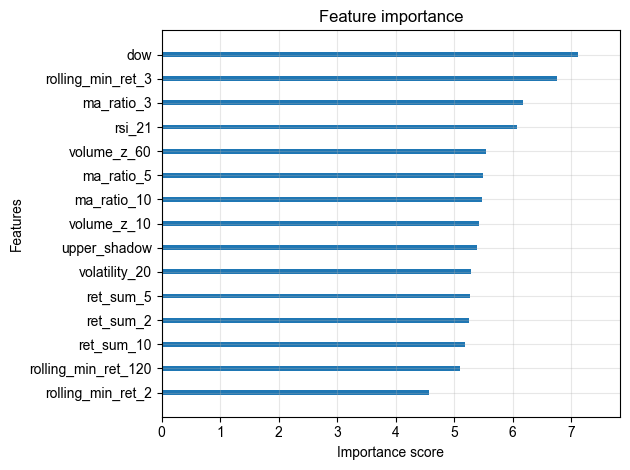

In [41]:
# Feature importance by gain
plot_importance(tuned_model, importance_type="gain", show_values=False)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

#### (b) Backtest Analysis

The backtest converts classification results into a simple long-only signal: hold the CSI 300 index when the model predicts class 1 and stay in cash when it predicts class 0. Let the model signal be $s_t\in\{0,1\}$ and the next-day index log return be $r_{t+1}$. The strategy return is:

$$r^{strategy}_{t+1}=s_t\cdot r_{t+1}$$

The cumulative wealth curve is obtained by exponentiating cumulative log returns:

$$W_T=\exp\left(\sum_{t=1}^{T}r^{strategy}_t\right)$$

This backtest does not include transaction costs, slippage, or capacity constraints. It is therefore used only as an initial check of the economic meaning of the prediction signal.

In [42]:
# Optional add-on: simple backtest of predicted signals.
test_index = X_test.index
signal = pd.Series(y_pred, index=test_index, name="signal")
strategy_returns = signal * df.loc[test_index, "next_log_ret"]
buy_hold_returns = df.loc[test_index, "next_log_ret"]

def performance(log_returns, exposure):
    wealth = np.exp(log_returns.cumsum())
    annual_return = wealth.iloc[-1] ** (252 / len(log_returns)) - 1
    annual_volatility = log_returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_volatility if annual_volatility > 0 else np.nan
    drawdown = wealth / wealth.cummax() - 1
    return pd.Series({
        "total_return": wealth.iloc[-1] - 1,
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
        "exposure": exposure,
    })

backtest = pd.DataFrame({
    "strategy": performance(strategy_returns, signal.mean()),
    "buy_hold": performance(buy_hold_returns, 1.0),
})
backtest.round(4)

,strategy,buy_hold
total_return,0.1308,0.0197
annual_return,0.0418,0.0065
annual_volatility,0.1129,0.1523
sharpe,0.3705,0.0428
max_drawdown,-0.0913,-0.2663
exposure,0.4418,1.0000


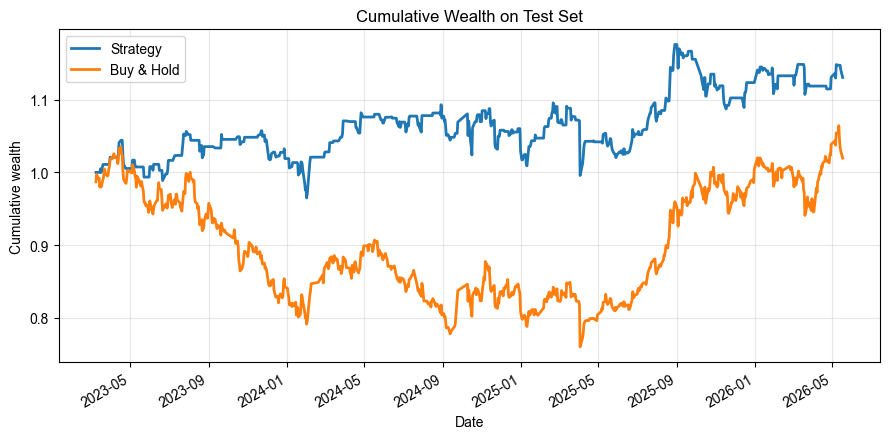

In [43]:
wealth = pd.DataFrame({
    "Strategy": np.exp(strategy_returns.cumsum()),
    "Buy & Hold": np.exp(buy_hold_returns.cumsum()),
})

fig, ax = plt.subplots(figsize=(9, 4.5))
wealth.plot(ax=ax, linewidth=2)
ax.set_title("Cumulative Wealth on Test Set")
ax.set_ylabel("Cumulative wealth")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

The tuned XGBoost model achieves a test ROC AUC above 0.5, indicating some ability to rank effective next-day uptrends, although the predictive power remains limited. This is consistent with the empirical difficulty of predicting short-term index returns, which are noisy and close to efficient.

The backtest provides an economic interpretation of the prediction signal, but it does not include transaction costs or slippage and should therefore be treated as supporting evidence rather than a standalone trading recommendation.